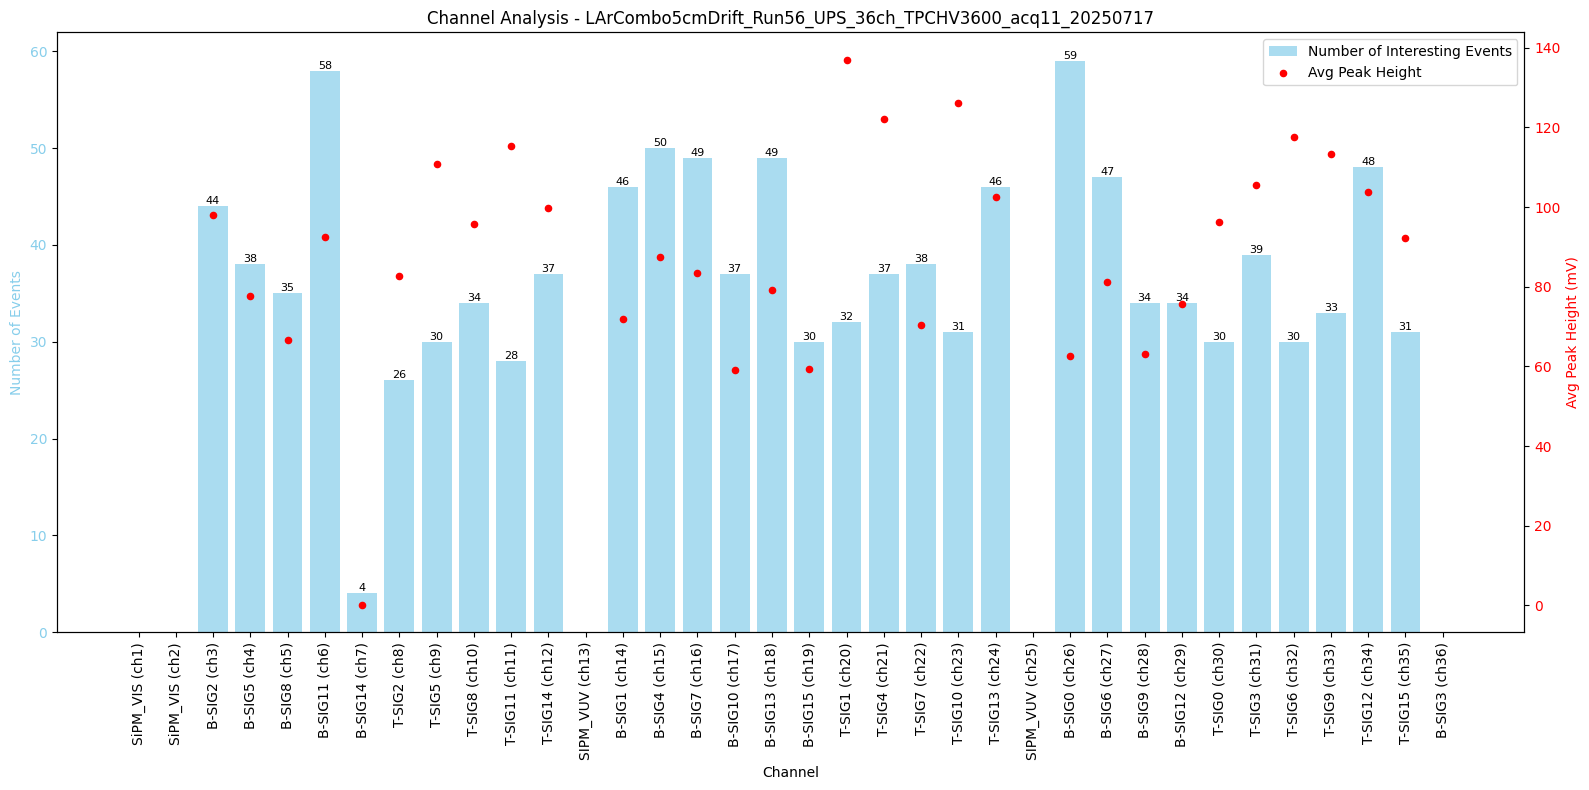

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
file_path = '/home/jiancheng/NAS/LAr_TPC_runs/Run56/LArCombo5cmDrift_Run56_UPS_36ch_TPCHV3600_acq11_20250717/CSP_interesting_events_stats.csv'
df = pd.read_csv(file_path, header=None)
parent_dir = os.path.basename(os.path.dirname(file_path))

# Extract data
events_row = df[df[0] == 'number of interesting events'].iloc[0]
peak_sum_row = df[df[0] == 'peak sum'].iloc[0]
# Extract the raw channel names and descriptions
channel_numbers = [f"ch{col}" for col in df.columns[1:]]  # Creates ch2, ch3, etc.
channel_descriptions = df.iloc[1, 1:].values  # Gets SiPM_VIS, B-SIG2, etc.

# Combine them in the format (ch2)SiPM_VIS
channels = [f"{desc} ({num})" for num, desc in zip(channel_numbers, channel_descriptions)]

# Convert to numeric
events_data = pd.to_numeric(events_row[1:], errors='coerce').fillna(0)
peak_sum_data = pd.to_numeric(peak_sum_row[1:], errors='coerce').fillna(0)

# Calculate average peak (safe division)
with np.errstate(divide='ignore', invalid='ignore'):
    avg_peak = np.where(events_data > 0, peak_sum_data/events_data, np.nan)

# Create plot with proper x-axis indexing
fig, ax1 = plt.subplots(figsize=(16, 8))
x = np.arange(len(channels))  # Create numeric x-axis positions

# Bar plot (events)
bars = ax1.bar(x, events_data, color='skyblue', alpha=0.7, width=0.8, label='Number of Interesting Events')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Number of Events', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=90)

# Scatter plot (average peaks)
ax2 = ax1.twinx()
scatter = ax2.scatter(x, avg_peak, color='red', s=20, label='Avg Peak Height', zorder=3)
ax2.set_ylabel('Avg Peak Height (mV)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add value labels to bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=8)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f"Channel Analysis - {parent_dir}")
plt.tight_layout()
plt.show()